# Flood-Mapping RAG — Extraction & Analysis

**Pipeline:**  ChromaDB (flood_papers) → semantic retrieval → regex extraction → structured DataFrame → analysis + figures

Run from the `paper_satelit/` project root with the `.venv` kernel active.

In [1]:
# ── CELL 1 — Imports ────────────────────────────────────────────────────────
import sys
import re
import logging
import os
import warnings
from pathlib import Path
from statistics import mean as _mean
from collections import defaultdict

# Suppress before any HF/tqdm imports so warnings never reach the kernel log
warnings.filterwarnings("ignore")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)
logging.getLogger("huggingface_hub.utils._http").setLevel(logging.ERROR)

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import chromadb
from chromadb.config import Settings
from sentence_transformers import SentenceTransformer

matplotlib.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

# Project root is the directory containing this notebook
PROJECT_ROOT = Path(".").resolve()
print(f"Project root : {PROJECT_ROOT}")
print(f"pandas {pd.__version__}  |  numpy {np.__version__}  |  chromadb {chromadb.__version__}")

Project root : /home/niko_notebook/projects/paper_satelit
pandas 3.0.2  |  numpy 2.4.4  |  chromadb 1.5.8


In [ ]:
# ── CELL M1 — PDF Metadata Extraction ───────────────────────────────────────
# Extracts Title, Authors, DOI, Abstract from every PDF using fitz (PyMuPDF).
# Result: paper_metadata  {filename -> {Title, Authors, DOI, Abstract, _abstract_text}}

import fitz as _fitz   # PyMuPDF — already a project dependency

LITERATURE_DIR = PROJECT_ROOT / "data" / "data" / "literature"

_DOI_RE = re.compile(r'\b(10\.\d{4,9}/[-._;\'"()/: A-Za-z0-9]+)', re.IGNORECASE)

# Common journal-section headers that appear before the real title (skip these)
_SKIP_TITLE_LINES = {
    "research papers", "research article", "original article", "full length article",
    "full-length article", "letter", "short communication", "review article",
    "technical note", "article", "paper", "open access", "contents lists available",
}
# Skip lines that look like journal volume headers (e.g. "Remote Sensing of Environment 282 (2022) 113273")
_JOURNAL_HEADER_RE = re.compile(r'\b(20\d{2})\b.*\b\d{5,}\b|\bvol\.?\s*\d+\b', re.IGNORECASE)


def _extract_doi(text: str) -> str | None:
    m = _DOI_RE.search(text)
    return m.group(1).rstrip(".,) ") if m else None


def _extract_abstract(text: str) -> str | None:
    """Return abstract text, handling both plain 'Abstract' and Elsevier 'A B S T R A C T'."""
    # Normalise spaced-letter header (e.g. "A B S T R A C T" -> "ABSTRACT")
    normalised = re.sub(r'\bA\s+B\s+S\s+T\s+R\s+A\s+C\s+T\b', 'ABSTRACT', text)
    m = re.search(
        r'(?i)\babstract\b[:\s]*(.+?)(?=\n\s*\n[0-9A-Z]|\n\s*(?:1\.\s|Introduction|Keywords|Background|K\s+E\s+Y))',
        normalised, re.DOTALL
    )
    if m:
        return " ".join(m.group(1).strip().split())[:2500]
    # Simpler fallback
    m2 = re.search(r'(?i)\babstract[:\s\n]+(.{200,2000})', normalised, re.DOTALL)
    if m2:
        return " ".join(m2.group(1).strip().split())[:2500]
    return None


def _extract_title(pages_text: list) -> str:
    """Heuristic: first substantive line on page 1 (mixed case, not a section header)."""
    for page in pages_text[:2]:
        for line in page.splitlines():
            line = line.strip()
            if len(line) < 12 or len(line) > 300:
                continue
            if line.isupper():
                continue
            if line.lower() in _SKIP_TITLE_LINES:
                continue
            upper_ratio = sum(1 for c in line if c.isupper()) / max(len(line), 1)
            if upper_ratio < 0.7:
                # Skip lines that are journal volume/page references
                if not _JOURNAL_HEADER_RE.search(line):
                    return line
    return "Unknown"


def _extract_authors(text: str) -> str | None:
    """Heuristic: comma-separated Name Surname pattern near start of document."""
    m = re.search(
        r'\b([A-Z][a-z]+(?:\s+[A-Z]\.?){0,2}(?:\s+[A-Z][a-z]+)?'
        r'(?:\s*,\s*[A-Z][a-z]+(?:\s+[A-Z]\.?){0,2}(?:\s+[A-Z][a-z]+)?){1,})\b',
        text[:4000]
    )
    return m.group(1)[:300] if m else None


def extract_paper_metadata(pdf_path) -> dict:
    """Return metadata dict for one PDF. Never raises."""
    out = {"Title": "Unknown", "Authors": None, "DOI": None, "Abstract": None,
           "_abstract_text": ""}
    try:
        doc = _fitz.open(str(pdf_path))
        pages_text = [doc.load_page(i).get_text("text")
                      for i in range(min(5, doc.page_count))]
        doc.close()
        combined = "\n".join(pages_text)
        out["Title"]    = _extract_title(pages_text)
        out["Authors"]  = _extract_authors(combined)
        out["DOI"]      = _extract_doi(combined)
        abstract        = _extract_abstract(combined)
        out["Abstract"] = abstract
        title_str       = out["Title"] or ""
        abstract_str    = abstract or combined[:1800]
        out["_abstract_text"] = f"Title: {title_str}\n\nAbstract: {abstract_str}"
    except Exception:
        pass   # out already has safe defaults
    return out


# ── Run on all PDFs ───────────────────────────────────────────────────────────
_pdf_paths = sorted(LITERATURE_DIR.glob("*.pdf"))
print(f"Scanning {len(_pdf_paths)} PDFs for metadata ...")

paper_metadata: dict = {}
_doi_count      = 0
_abstract_count = 0

for _p in _pdf_paths:
    _m = extract_paper_metadata(_p)
    paper_metadata[_p.name] = _m
    if _m["DOI"]:       _doi_count      += 1
    if _m["Abstract"]:  _abstract_count += 1

_total = len(paper_metadata)
print(f"  Total PDFs        : {_total}")
print(f"  DOI found         : {_doi_count} / {_total}  ({100*_doi_count//_total}%)")
print(f"  Abstract found    : {_abstract_count} / {_total}  ({100*_abstract_count//_total}%)")
if _doi_count < _total * 0.5:
    print(f"  [WARN] Fewer than 50% of papers have a parseable DOI — "
          f"Source_File is used as unique key in the final dataset.")


In [ ]:
# ── CELL M2 — Primary LLM Extraction (Title + Abstract) ─────────────────────
# For each paper: send ONLY Title+Abstract to the LLM as the PRIMARY signal.
# Stores results in abstract_llm_results {filename → parsed_dict}.

ABSTRACT_LLM_TIMEOUT = 60   # seconds — abstracts are short

_ABSTRACT_PROMPT_TEMPLATE = (
    "You are an expert in flood mapping remote-sensing literature.\n"
    "Read the TITLE and ABSTRACT of a scientific paper and extract the fields below.\n"
    "Return ONLY valid JSON — no markdown, no extra text.\n\n"
    "Fields:\n"
    '  "Method": string — main classification/mapping method'
    " (e.g. Random Forest, U-Net, SAR thresholding, SVM, CNN),\n"
    '  "Sensor": string — primary sensor/data source'
    " (e.g. Sentinel-1, Sentinel-2, Landsat-8, SAR, optical, multispectral, UAV),\n"
    '  "Region": string or null — geographic study area,\n'
    '  "OA":  float or null — Overall Accuracy 0-1 (convert % to fraction),\n'
    '  "F1":  float or null — F1-score 0-1,\n'
    '  "IoU": float or null — IoU / Jaccard Index 0-1,\n'
    '  "Accuracy_Description": string or null —'
    " 3-10 word phrase about accuracy when no numeric values are present\n\n"
    "Rules:\n"
    "  - Normalise all metrics to 0-1 range.\n"
    "  - Prefer explicit numbers over vague descriptions.\n"
    "  - Unknown / not mentioned -> null.\n\n"
    "{text}"
)


def _extract_from_abstract(abstract_text: str, timeout: int = 60) -> dict | None:
    """Send Title+Abstract text to Ollama; return parsed dict or None."""
    prompt = _ABSTRACT_PROMPT_TEMPLATE.format(text=abstract_text)
    payload = {
        "model":   OLLAMA_MODEL,
        "prompt":  prompt,
        "stream":  False,
        "options": {"temperature": 0.0},
    }
    try:
        resp = requests.post(OLLAMA_URL, json=payload, timeout=timeout)
        resp.raise_for_status()
        raw = resp.json().get("response", "").strip()
        if raw.startswith("```"):
            raw = raw.split("```")[1]
            if raw.startswith("json"):
                raw = raw[4:]
        return _json.loads(raw)
    except requests.exceptions.ConnectionError:
        return None
    except (_json.JSONDecodeError, KeyError, requests.RequestException) as exc:
        print(f"  [WARN] abstract-LLM parse error: {exc}")
        return None


print(f"Primary LLM extraction — Title + Abstract ...")
print(f"  Papers to process : {len(paper_metadata)}")
print(f"  Model             : {OLLAMA_MODEL}\n")

abstract_llm_results: dict[str, dict] = {}
_ab_errors      = 0
_ab_consecutive = 0

for _fname, _meta in paper_metadata.items():
    _text = _meta.get("_abstract_text", "")
    if not _text:
        continue

    _parsed = _extract_from_abstract(_text, timeout=ABSTRACT_LLM_TIMEOUT)

    if _parsed is None:
        _ab_errors      += 1
        _ab_consecutive += 1
        if _ab_consecutive >= MAX_CONSECUTIVE_FAILURES:
            print(f"  [CIRCUIT-BREAKER] Ollama offline — stopped after "
                  f"{_ab_consecutive} failures.")
            break
        continue

    _ab_consecutive = 0
    abstract_llm_results[_fname] = _parsed

    n_done = len(abstract_llm_results)
    if n_done % 25 == 0:
        print(f"  [{n_done:3d}/{len(paper_metadata)}]  ok={n_done}  err={_ab_errors}")

print(f"\nAbstract-LLM extraction complete.")
print(f"  Successful : {len(abstract_llm_results)} / {len(paper_metadata)}")
print(f"  Errors     : {_ab_errors}")
if not abstract_llm_results:
    print("  [WARN] No abstract-LLM results — chunk-based extraction is the only LLM signal.")


In [3]:
# ── CELL 2 — Connect to ChromaDB ────────────────────────────────────────────
CHROMA_DIR      = PROJECT_ROOT / ".chromadb"
COLLECTION_NAME = "flood_papers"

assert CHROMA_DIR.exists(), f"ChromaDB not found at {CHROMA_DIR}. Run ingest first."

client = chromadb.PersistentClient(
    path=str(CHROMA_DIR),
    settings=Settings(anonymized_telemetry=False),
)
collection = client.get_collection(name=COLLECTION_NAME)

total_chunks = collection.count()
print(f"Collection  : '{COLLECTION_NAME}'")
print(f"Total chunks: {total_chunks:,}")
assert total_chunks > 0, "Collection is empty — run main.py --ingest first."

Collection  : 'flood_papers'
Total chunks: 13,970


In [4]:
# ── CELL 3 — Semantic Retrieval (UPGRADED: TOP_K=50, 10 queries) ─────────────
import os
os.environ.setdefault("HF_HOME", "/tmp/hf_cache")   # user-writable HF cache

EMBEDDING_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
TOP_K = 50    # ↑ was 15 — ensures multi-chunk coverage per paper

QUERIES = [
    # Core accuracy / metrics
    "flood mapping accuracy OA F1 IoU Kappa overall accuracy",
    "flood detection precision recall F1-score confusion matrix",
    # Method-specific
    "SAR Sentinel-1 flood mapping accuracy performance results",
    "deep learning U-Net CNN flood segmentation F1 IoU metrics",
    "random forest SVM machine learning flood overall accuracy Kappa",
    "optical satellite Sentinel-2 Landsat flood mapping accuracy",
    # Evaluation language
    "flood extent validation accuracy assessment comparison reference data",
    "flood classification performance evaluation benchmark results table",
    # Sensor / region-specific
    "microwave radar backscatter flood inundation mapping accuracy",
    "multispectral optical imagery flood water detection evaluation",
]

print(f"Loading embedding model: {EMBEDDING_MODEL} …")
encoder = SentenceTransformer(EMBEDDING_MODEL)
print(f"Model ready. Running {len(QUERIES)} queries × TOP_K={TOP_K}\n")

seen_ids: set = set()
all_hits: list = []

for q in QUERIES:
    vec = encoder.encode(q, normalize_embeddings=True).tolist()
    results = collection.query(
        query_embeddings=[vec],
        n_results=min(TOP_K, total_chunks),
        include=["documents", "metadatas", "distances"],
    )
    for doc, meta, dist, cid in zip(
        results["documents"][0],
        results["metadatas"][0],
        results["distances"][0],
        results["ids"][0],
    ):
        if cid in seen_ids:
            continue
        seen_ids.add(cid)
        all_hits.append({
            "text":       doc,
            "chunk_id":   cid,
            "filename":   meta.get("filename", ""),
            "page_start": meta.get("page_start", 0),
            "page_end":   meta.get("page_end",   0),
            "distance":   dist,
        })
    print(f"  [{q[:60]:<60}]  cumulative unique chunks: {len(all_hits):4d}")

# Group by source file; sort each paper's chunks by relevance score
by_file: dict = defaultdict(list)
for hit in all_hits:
    by_file[hit["filename"]].append(hit)
for fname in by_file:
    by_file[fname].sort(key=lambda h: h["distance"])

print(f"\n{'─'*60}")
print(f"Unique chunks retrieved : {len(all_hits):,}")
print(f"Unique source files     : {len(by_file):,}")
print(f"Avg chunks / paper      : {len(all_hits)/max(len(by_file),1):.1f}")
print(f"\nTop 10 files by chunk count:")
top10 = sorted(by_file.items(), key=lambda x: len(x[1]), reverse=True)[:10]
for fname, hits in top10:
    print(f"  {Path(fname).stem[:58]:<58}  {len(hits):3d} chunks")

# Coverage check
single_chunk = sum(1 for v in by_file.values() if len(v) == 1)
print(f"\nPapers with only 1 chunk : {single_chunk} / {len(by_file)} "
      f"({'consider ↑ TOP_K further' if single_chunk > len(by_file)*0.3 else 'OK'})")


Loading embedding model: sentence-transformers/all-MiniLM-L6-v2 …


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3893.63it/s]


Model ready.

  [flood mapping accuracy OA F1 IoU Kappa overall accuracy]  cumulative unique chunks: 15
  [remote sensing flood detection sensor method classifica]  cumulative unique chunks: 30
  [SAR Sentinel-1 flood mapping accuracy performance resul]  cumulative unique chunks: 45
  [deep learning U-Net CNN flood segmentation F1 IoU metri]  cumulative unique chunks: 60
  [random forest SVM machine learning flood overall accura]  cumulative unique chunks: 75
  [optical satellite flood mapping Sentinel-2 Landsat accu]  cumulative unique chunks: 87

────────────────────────────────────────────────────────────
Unique chunks retrieved : 87
Unique source files     : 54

Top 10 files by chunk count:
  sensors-22-00960                                           4 chunks
  remotesensing-17-02909                                     4 chunks
  ijgi-12-00194-v2                                           4 chunks
  remotesensing-15-01200                                     3 chunks
  remotesensing-

In [5]:
# ── CELL 4 — Information Extraction ─────────────────────────────────────────
# Regex patterns mirror src/extraction/regex_extractor.py exactly.

_NUM   = r"([\d]+\.?[\d]*)"
_PCT   = r"%?"
_SEP   = r"\s*[=:>]?\s*"
_RANGE = rf"{_NUM}\s*[-\u2013]\s*{_NUM}"

def _r(p):
    return re.compile(p, re.IGNORECASE)

OA_PATTERNS = [
    _r(rf"[Oo]verall\s+[Aa]ccuracy{_SEP}{_RANGE}{_PCT}"),
    _r(rf"\bOA{_SEP}{_RANGE}{_PCT}"),
    _r(rf"[Oo]verall\s+[Aa]ccuracy{_SEP}{_NUM}{_PCT}"),
    _r(rf"\bOA\b{_SEP}{_NUM}{_PCT}"),
    _r(rf"[Aa]ccuracy\s+of\s+{_NUM}{_PCT}"),
    _r(rf"[Aa]ccuracy\s+rate{_SEP}{_NUM}{_PCT}"),
    _r(rf"[Aa]ccuracy{_SEP}{_NUM}{_PCT}"),
]
F1_PATTERNS = [
    _r(rf"[Ff]1[-\s]*[Ss]core{_SEP}{_RANGE}"),
    _r(rf"\bF[-\s]?1{_SEP}{_RANGE}"),
    _r(rf"[Ff]1[-\s]*[Ss]core{_SEP}{_NUM}"),
    _r(rf"\bF[-\s]?1\b{_SEP}{_NUM}"),
    _r(rf"[Ff]-[Mm]easure{_SEP}{_NUM}"),
    _r(rf"[Ff][-\s]score{_SEP}{_NUM}"),
]
IOU_PATTERNS = [
    _r(rf"\bIoU{_SEP}{_RANGE}"),
    _r(rf"\bIoU\b{_SEP}{_NUM}"),
    _r(rf"[Ii]ntersection\s+[Oo]ver\s+[Uu]nion{_SEP}{_NUM}"),
    _r(rf"\bmIoU\b{_SEP}{_NUM}"),
    _r(rf"[Jj]accard\s+[Ii]ndex{_SEP}{_NUM}"),
    _r(rf"[Jj]accard{_SEP}{_NUM}"),
]

# Method keyword banks
_DL_KW  = ["u-net","unet","convolutional neural network","cnn","fcnn",
            "resnet","efficientnet","segnet","basnet","fsa-unet","deeplab",
            "vision transformer","vit","lstm","attention unet",
            "fully convolutional","deep learning","semantic segmentation"]
_ML_KW  = ["random forest","support vector machine","svm","decision tree",
            "gradient boosting","xgboost","naive bayes","logistic regression",
            "maximum likelihood","mlc","cart","k-nearest","k-means",
            "machine learning","multilayer perceptron","mlp"]
_SAR_KW = ["thresholding","otsu","object-based","obia","insar","backscatter",
            "change detection","multi-temporal","hysteresis","histogram threshold",
            "rapid","rst-flood","gumbel","repeat-pass sar","depth estimation"]

_SAR_SENSORS = ["sentinel-1","terrasar-x","uavsar","cosmo-skymed","alos",
                "radarsat","ers","envisat","novasar"]
_OPT_SENSORS = ["sentinel-2","landsat","modis","viirs","worldview",
                "pleiades","spot","planet","aerial","google earth"]

_KNOWN_REGIONS = ["australia","bangladesh","china","croatia","england","france",
                  "germany","india","italy","japan","mexico","moldova","morocco",
                  "myanmar","netherlands","pakistan","poland","romania","slovenia",
                  "spain","ukraine","united kingdom","united states","usa","uk",
                  "conus","texas","california","florida","vietnam","global"]


def _parse_number(raw: str) -> float:
    num = float(raw.replace(",", "."))
    return num / 100.0 if num > 1.0 else num


def _extract_metric(text: str, patterns: list) -> float | None:
    for pat in patterns:
        for m in pat.finditer(text):
            groups = [g for g in m.groups() if g is not None]
            if len(groups) == 2:
                try:
                    lo, hi = _parse_number(groups[0]), _parse_number(groups[1])
                    if 0.0 <= lo <= hi <= 1.0:
                        return round(_mean([lo, hi]), 4)
                except ValueError:
                    continue
            elif len(groups) == 1:
                try:
                    val = _parse_number(groups[0])
                    if 0.0 <= val <= 1.0:
                        return round(val, 4)
                except ValueError:
                    continue
    return None


def _classify_method(text: str) -> str:
    tl = text.lower()
    dl  = sum(1 for kw in _DL_KW  if kw in tl)
    ml  = sum(1 for kw in _ML_KW  if kw in tl)
    sar = sum(1 for kw in _SAR_KW if kw in tl)
    scores = {"Deep Learning": dl, "Machine Learning": ml, "SAR/Threshold": sar}
    top = max(scores, key=scores.get)
    snippet = tl[:3000]
    kw_map = {"Deep Learning": _DL_KW, "Machine Learning": _ML_KW, "SAR/Threshold": _SAR_KW}
    for kw in kw_map[top]:
        if kw in snippet:
            return kw.title()
    return top if scores[top] > 0 else "Unknown"


def _detect_sensors(text: str) -> str:
    tl = text.lower()
    seen, out = set(), []
    for s in _SAR_SENSORS + _OPT_SENSORS:
        if s in tl and s not in seen:
            seen.add(s)
            out.append(s.title())
    return ", ".join(out[:5]) if out else "Unknown"


def _detect_region(text: str) -> str:
    tl = text.lower()
    seen, out = set(), []
    for r in _KNOWN_REGIONS:
        if r in tl and r not in seen:
            seen.add(r)
            out.append(r.title())
    return ", ".join(out[:4]) if out else "Unknown"


def _accuracy_desc(oa, f1, iou) -> str:
    parts = []
    if oa  is not None: parts.append(f"OA={oa:.3f}")
    if f1  is not None: parts.append(f"F1={f1:.3f}")
    if iou is not None: parts.append(f"IoU={iou:.3f}")
    return ", ".join(parts) if parts else "No numeric metrics extracted"


def _accuracy_level(oa, f1, iou) -> str:
    n = sum(v is not None for v in [oa, f1, iou])
    if n >= 2: return "Quantitative"
    if n == 1: return "Semi-quantitative"
    return "Qualitative"


def extract_from_chunks(filename: str, chunks: list) -> dict:
    combined = "\n\n".join(c["text"] for c in chunks)
    oa  = _extract_metric(combined, OA_PATTERNS)
    f1  = _extract_metric(combined, F1_PATTERNS)
    iou = _extract_metric(combined, IOU_PATTERNS)
    return {
        "Source_File":    filename,
        "Method":         _classify_method(combined),
        "Sensor":         _detect_sensors(combined),
        "Region":         _detect_region(combined),
        "OA":             oa,
        "F1":             f1,
        "IoU":            iou,
        "Accuracy_Desc":  _accuracy_desc(oa, f1, iou),
        "Accuracy_Level": _accuracy_level(oa, f1, iou),
    }


print(f"Running extraction across {len(by_file)} source files …")
raw_records = [extract_from_chunks(fname, chunks) for fname, chunks in by_file.items()]

n_oa  = sum(1 for r in raw_records if r["OA"]  is not None)
n_f1  = sum(1 for r in raw_records if r["F1"]  is not None)
n_iou = sum(1 for r in raw_records if r["IoU"] is not None)
print(f"Extraction complete: {len(raw_records)} records")
print(f"  OA  extracted : {n_oa}")
print(f"  F1  extracted : {n_f1}")
print(f"  IoU extracted : {n_iou}")

Running extraction across 54 source files …
Extraction complete: 54 records
  OA  extracted : 8
  F1  extracted : 1
  IoU extracted : 0


In [6]:
# ── CELL 5 — Build DataFrame ─────────────────────────────────────────────────
COLUMNS = ["Source_File", "Method", "Sensor", "Region",
           "OA", "F1", "IoU",
           "Accuracy_Desc", "Accuracy_Level"]

df_raw = pd.DataFrame(raw_records, columns=COLUMNS)

# Cast metric columns to float (they may be None from extraction)
for col in ["OA", "F1", "IoU"]:
    df_raw[col] = pd.to_numeric(df_raw[col], errors="coerce")

print(f"DataFrame shape: {df_raw.shape}")
print(f"\nColumn dtypes:")
print(df_raw.dtypes.to_string())
print(f"\nNull counts:")
print(df_raw.isnull().sum().to_string())
df_raw[["Source_File", "Method", "Sensor", "OA", "F1", "IoU", "Accuracy_Level"]].head(12)

DataFrame shape: (54, 9)

Column dtypes:
Source_File           str
Method                str
Sensor                str
Region                str
OA                float64
F1                float64
IoU               float64
Accuracy_Desc         str
Accuracy_Level        str

Null counts:
Source_File        0
Method             0
Sensor             0
Region             0
OA                46
F1                53
IoU               54
Accuracy_Desc      0
Accuracy_Level     0


,Source_File,Method,Sensor,OA,F1,IoU,Accuracy_Level
0,remotesensing-16-02193.pdf,Rst-Flood,"Radarsat, Ers",0.8500,NaN,NaN,Semi-quantitative
1,Flood_Extent_Mapping_in_the_Caprivi_Floodplain...,Unknown,"Sentinel-1, Landsat",NaN,NaN,NaN,Qualitative
2,Mapping_Water_Bodies_and_Wetlands_from_M.pdf,Unknown,Unknown,NaN,NaN,NaN,Qualitative
3,water-16-00407-v2.pdf,Unknown,Unknown,NaN,NaN,NaN,Qualitative
4,Flood_extent_delineation_using_Sentinel.pdf,Random Forest,"Sentinel-1, Ers, Landsat",0.8800,NaN,NaN,Semi-quantitative
5,remotesensing-15-01200.pdf,Thresholding,"Sentinel-1, Ers, Sentinel-2",NaN,NaN,NaN,Qualitative
6,034505_1.pdf,Thresholding,Sentinel-1,NaN,NaN,NaN,Qualitative
7,remotesensing-11-01581-v2.pdf,Unknown,"Sentinel-1, Ers, Landsat",0.9644,NaN,NaN,Semi-quantitative
8,remotesensing-16-00656-v2.pdf,Random Forest,"Sentinel-1, Ers, Landsat",NaN,NaN,NaN,Qualitative
9,s41598-021-86650-z.pdf,U-Net,"Ers, Sentinel-2, Google Earth",NaN,NaN,NaN,Qualitative


In [7]:
# ── CELL 6 — Cleaning & Processing ──────────────────────────────────────────
df = df_raw.copy()

# Drop exact-duplicate source files (shouldn't happen, defensive)
df = df.drop_duplicates(subset=["Source_File"])

# All numeric metrics already normalised 0–1 by _parse_number() in Cell 4.
# Guard: clip any stray values outside valid range.
for col in ["OA", "F1", "IoU"]:
    df[col] = df[col].clip(0.0, 1.0)

# Recompute Accuracy_Level from actual columns (overrides extracted string)
def _level(row):
    n = row[["OA", "F1", "IoU"]].notna().sum()
    if n >= 2: return "Quantitative"
    if n == 1: return "Semi-quantitative"
    return "Qualitative"

df["Accuracy_Level"] = df.apply(_level, axis=1)

# Accuracy_Main  →  priority: F1 > OA > IoU
def _accuracy_main(row):
    for col in ["F1", "OA", "IoU"]:
        if pd.notna(row[col]):
            return row[col]
    return np.nan

df["Accuracy_Main"] = df.apply(_accuracy_main, axis=1)

# Short label for plots
df["Label"] = df["Source_File"].apply(lambda p: Path(p).stem[:45])

print("Cleaned DataFrame — key columns:")
print(df[["Label", "Method", "Sensor", "OA", "F1", "IoU",
          "Accuracy_Main", "Accuracy_Level"]].to_string(index=False))

Cleaned DataFrame — key columns:
                                        Label                       Method                                           Sensor     OA   F1  IoU  Accuracy_Main    Accuracy_Level
                       remotesensing-16-02193                    Rst-Flood                                    Radarsat, Ers 0.8500  NaN  NaN         0.8500 Semi-quantitative
Flood_Extent_Mapping_in_the_Caprivi_Floodplai                      Unknown                              Sentinel-1, Landsat    NaN  NaN  NaN            NaN       Qualitative
     Mapping_Water_Bodies_and_Wetlands_from_M                      Unknown                                          Unknown    NaN  NaN  NaN            NaN       Qualitative
                            water-16-00407-v2                      Unknown                                          Unknown    NaN  NaN  NaN            NaN       Qualitative
      Flood_extent_delineation_using_Sentinel                Random Forest                       

In [8]:
# ── CELL 7 — Analysis ────────────────────────────────────────────────────────
n_total = len(df)
n_quant = (df["Accuracy_Level"] == "Quantitative").sum()
n_semi  = (df["Accuracy_Level"] == "Semi-quantitative").sum()
n_qual  = (df["Accuracy_Level"] == "Qualitative").sum()

q_df = df[df["Accuracy_Main"].notna()].copy()  # papers with any numeric metric

SEP = "=" * 65

print(SEP)
print(f"CORPUS OVERVIEW  ({n_total} files)")
print(SEP)
print(f"  Quantitative    : {n_quant:3d}  ({100*n_quant/n_total:.1f}%)")
print(f"  Semi-quantitative: {n_semi:3d}  ({100*n_semi/n_total:.1f}%)")
print(f"  Qualitative     : {n_qual:3d}  ({100*n_qual/n_total:.1f}%)")

print(f"\n{SEP}")
print("ACCURACY_MAIN — OVERALL STATISTICS (studies with any numeric metric)")
print(SEP)
if len(q_df) > 0:
    print(q_df["Accuracy_Main"].describe().round(4).to_string())
else:
    print("No numeric data extracted.")

print(f"\n{SEP}")
print("ACCURACY_MAIN BY METHOD  (methods with ≥1 numeric result)")
print(SEP)
method_stats = (
    q_df.groupby("Method")["Accuracy_Main"]
    .agg(count="count", mean="mean", min="min", max="max", std="std")
    .round(4)
    .sort_values("mean", ascending=False)
)
print(method_stats.to_string() if len(method_stats) else "No data.")

print(f"\n{SEP}")
print("ACCURACY_MAIN BY SENSOR  (sensors with ≥1 numeric result)")
print(SEP)
sensor_stats = (
    q_df.groupby("Sensor")["Accuracy_Main"]
    .agg(count="count", mean="mean", min="min", max="max", std="std")
    .round(4)
    .sort_values("mean", ascending=False)
)
print(sensor_stats.to_string() if len(sensor_stats) else "No data.")

print(f"\n{SEP}")
print("STUDY COUNT PER METHOD (all retrieved files)")
print(SEP)
print(df["Method"].value_counts().head(12).to_string())

print(f"\n{SEP}")
print("STUDY COUNT PER SENSOR (all retrieved files)")
print(SEP)
print(df["Sensor"].value_counts().head(12).to_string())

CORPUS OVERVIEW  (54 files)
  Quantitative    :   0  (0.0%)
  Semi-quantitative:   9  (16.7%)
  Qualitative     :  45  (83.3%)

ACCURACY_MAIN — OVERALL STATISTICS (studies with any numeric metric)
count    9.0000
mean     0.7267
std      0.4028
min      0.0200
25%      0.8500
50%      0.8983
75%      0.9644
max      1.0000

ACCURACY_MAIN BY METHOD  (methods with ≥1 numeric result)
               count    mean     min     max     std
Method                                              
Deep Learning      1  1.0000  1.0000  1.0000     NaN
U-Net              1  0.9880  0.9880  0.9880     NaN
Thresholding       2  0.9074  0.8983  0.9165  0.0129
Random Forest      1  0.8800  0.8800  0.8800     NaN
Rst-Flood          1  0.8500  0.8500  0.8500     NaN
Unknown            2  0.4922  0.0200  0.9644  0.6678
Unet               1  0.0230  0.0230  0.0230     NaN

ACCURACY_MAIN BY SENSOR  (sensors with ≥1 numeric result)
                                           count    mean     min     max     std

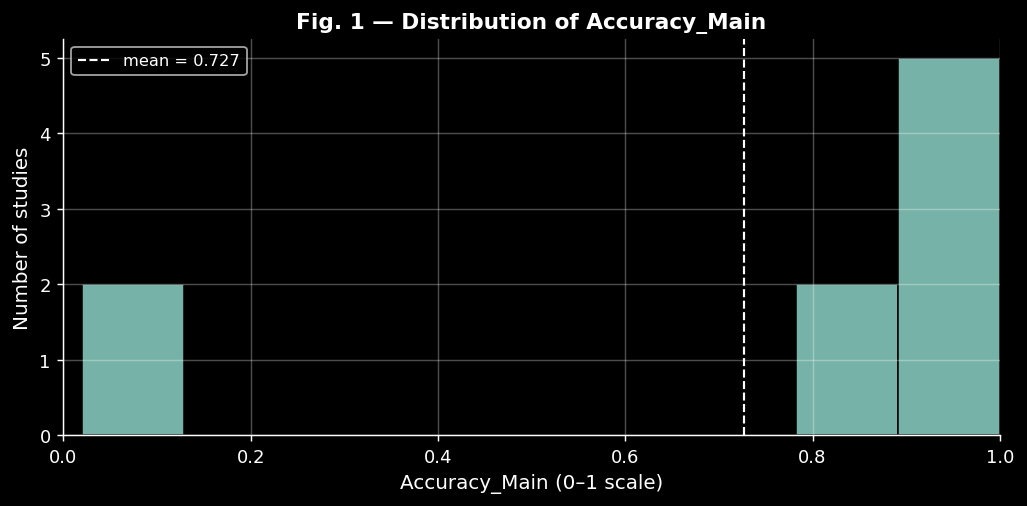

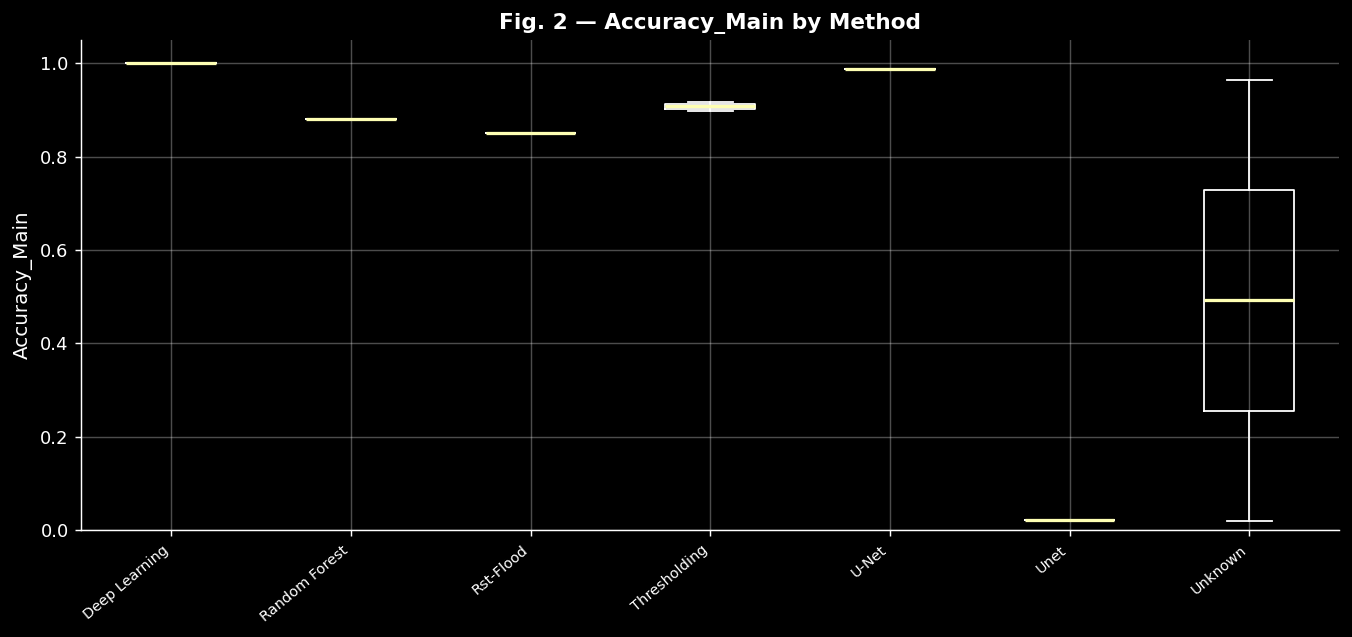

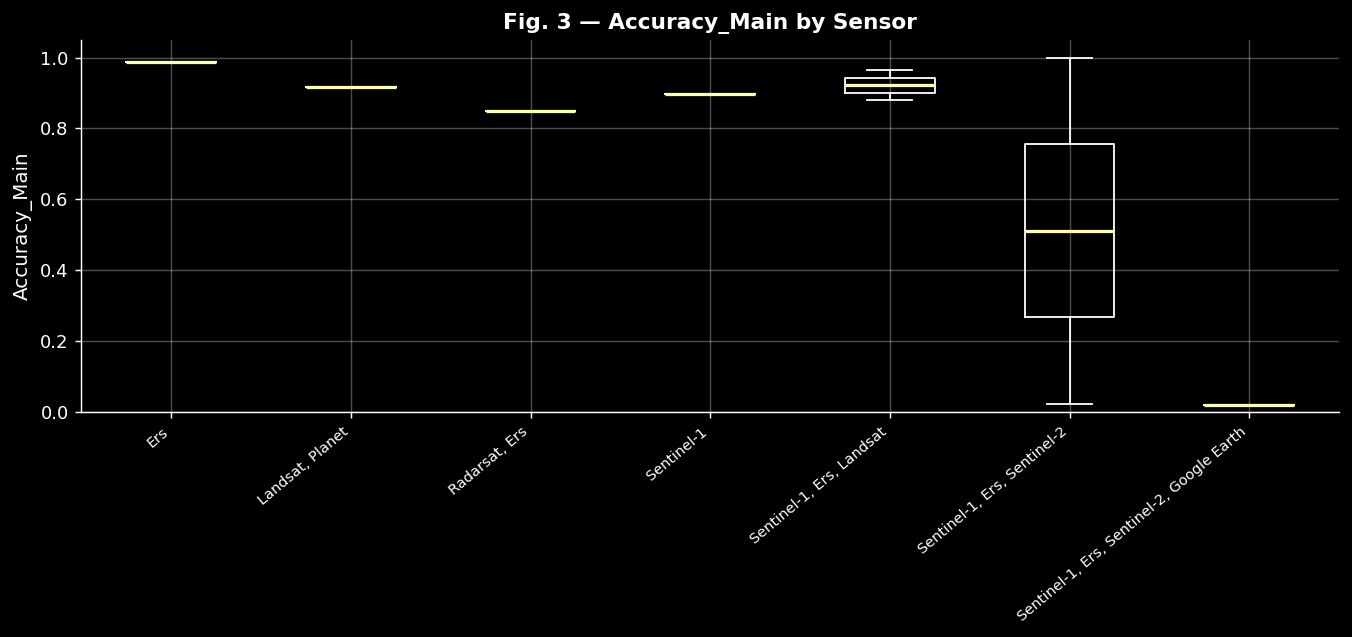

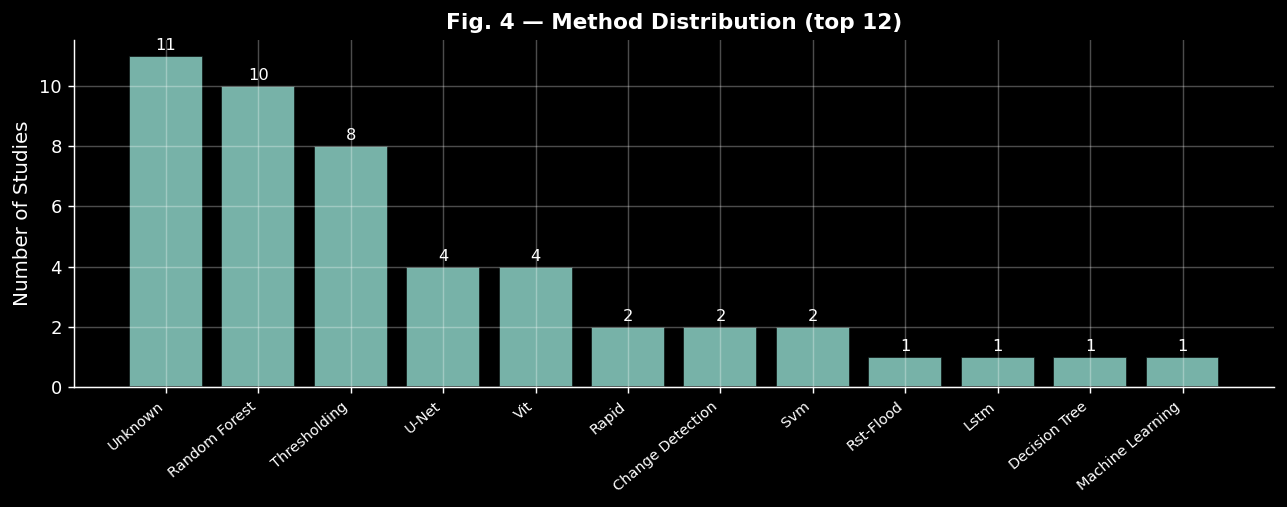

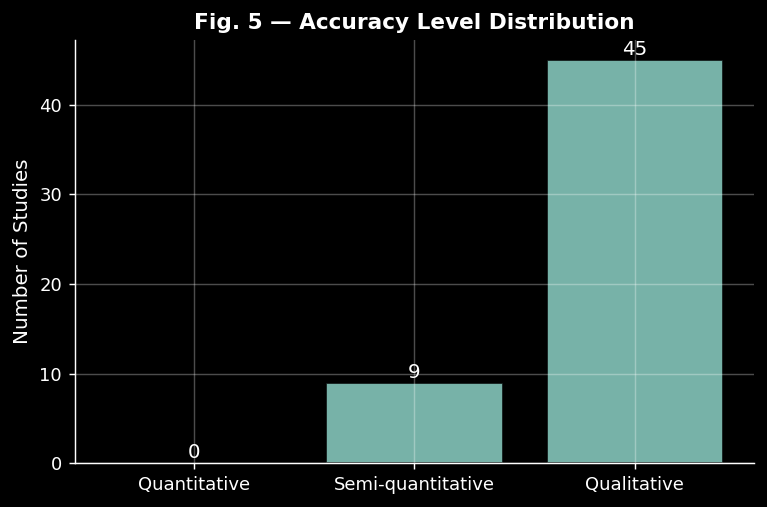


All figures saved to /home/niko_notebook/projects/paper_satelit/outputs


In [9]:
# ── CELL 8 — Visualizations (matplotlib only) ────────────────────────────────
OUT_DIR = PROJECT_ROOT / "outputs"
OUT_DIR.mkdir(exist_ok=True)

q_plot    = df[df["Accuracy_Main"].notna()].copy()
has_quant = len(q_plot) > 0


# ── 1. Histogram of Accuracy_Main ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
if has_quant:
    n_bins = max(5, min(20, len(q_plot)))
    ax.hist(q_plot["Accuracy_Main"], bins=n_bins, edgecolor="black", alpha=0.85)
    ax.axvline(q_plot["Accuracy_Main"].mean(), linestyle="--", linewidth=1.2,
               label=f'mean = {q_plot["Accuracy_Main"].mean():.3f}')
    ax.legend(fontsize=9)
else:
    ax.text(0.5, 0.5, "No quantitative data available",
            transform=ax.transAxes, ha="center", fontsize=12)
ax.set_xlabel("Accuracy_Main (0–1 scale)", fontsize=11)
ax.set_ylabel("Number of studies", fontsize=11)
ax.set_title("Fig. 1 — Distribution of Accuracy_Main", fontsize=12, fontweight="bold")
ax.set_xlim(0, 1)
plt.tight_layout()
plt.savefig(OUT_DIR / "fig1_accuracy_histogram.png", dpi=150)
plt.show()


# ── 2. Boxplot: Accuracy by Method ───────────────────────────────────────────
method_grps = {
    m: g["Accuracy_Main"].dropna().tolist()
    for m, g in q_plot.groupby("Method")
    if g["Accuracy_Main"].notna().sum() >= 1
}

fig, ax = plt.subplots(figsize=(max(7, len(method_grps) * 1.5), 5))
if method_grps:
    labels_m = list(method_grps.keys())
    data_m   = list(method_grps.values())
    ax.boxplot(data_m, labels=labels_m, patch_artist=False, notch=False,
               medianprops=dict(linewidth=1.8))
    ax.set_xticklabels(labels_m, rotation=40, ha="right", fontsize=8)
else:
    ax.text(0.5, 0.5, "Insufficient data", transform=ax.transAxes, ha="center")
ax.set_ylabel("Accuracy_Main", fontsize=11)
ax.set_title("Fig. 2 — Accuracy_Main by Method", fontsize=12, fontweight="bold")
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig(OUT_DIR / "fig2_boxplot_method.png", dpi=150)
plt.show()


# ── 3. Boxplot: Accuracy by Sensor ───────────────────────────────────────────
sensor_grps = {
    s: g["Accuracy_Main"].dropna().tolist()
    for s, g in q_plot.groupby("Sensor")
    if g["Accuracy_Main"].notna().sum() >= 1
}

fig, ax = plt.subplots(figsize=(max(7, len(sensor_grps) * 1.5), 5))
if sensor_grps:
    labels_s = list(sensor_grps.keys())
    data_s   = list(sensor_grps.values())
    ax.boxplot(data_s, labels=labels_s, patch_artist=False,
               medianprops=dict(linewidth=1.8))
    ax.set_xticklabels(labels_s, rotation=40, ha="right", fontsize=8)
else:
    ax.text(0.5, 0.5, "Insufficient data", transform=ax.transAxes, ha="center")
ax.set_ylabel("Accuracy_Main", fontsize=11)
ax.set_title("Fig. 3 — Accuracy_Main by Sensor", fontsize=12, fontweight="bold")
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig(OUT_DIR / "fig3_boxplot_sensor.png", dpi=150)
plt.show()


# ── 4. Bar chart: Method distribution ────────────────────────────────────────
method_counts = df["Method"].value_counts().head(12)

fig, ax = plt.subplots(figsize=(10, 4))
x_pos = range(len(method_counts))
ax.bar(x_pos, method_counts.values, edgecolor="black", alpha=0.85)
ax.set_xticks(x_pos)
ax.set_xticklabels(method_counts.index, rotation=40, ha="right", fontsize=8)
for i, v in enumerate(method_counts.values):
    ax.text(i, v + 0.1, str(v), ha="center", va="bottom", fontsize=9)
ax.set_ylabel("Number of Studies", fontsize=11)
ax.set_title("Fig. 4 — Method Distribution (top 12)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "fig4_method_distribution.png", dpi=150)
plt.show()


# ── 5. Bar chart: Accuracy_Level distribution ─────────────────────────────────
level_order  = ["Quantitative", "Semi-quantitative", "Qualitative"]
level_counts = df["Accuracy_Level"].value_counts().reindex(level_order, fill_value=0)

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(level_counts.index, level_counts.values, edgecolor="black", alpha=0.85)
for bar, v in zip(bars, level_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.1,
            str(v), ha="center", va="bottom", fontsize=11)
ax.set_ylabel("Number of Studies", fontsize=11)
ax.set_title("Fig. 5 — Accuracy Level Distribution", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "fig5_accuracy_level.png", dpi=150)
plt.show()

print(f"\nAll figures saved to {OUT_DIR}")

In [10]:
# ── CELL 9 — Key Insights (auto-generated scientific text) ───────────────────
acc_vals = df["Accuracy_Main"].dropna()

# Core stats
n_total = len(df)
n_quant = (df["Accuracy_Level"] == "Quantitative").sum()
n_semi  = (df["Accuracy_Level"] == "Semi-quantitative").sum()
n_qual  = (df["Accuracy_Level"] == "Qualitative").sum()
pct_no  = round(100 * n_qual / n_total, 1) if n_total else 0

acc_mean = acc_vals.mean()   if len(acc_vals) else float("nan")
acc_min  = acc_vals.min()    if len(acc_vals) else float("nan")
acc_max  = acc_vals.max()    if len(acc_vals) else float("nan")
acc_std  = acc_vals.std()    if len(acc_vals) else float("nan")
acc_med  = acc_vals.median() if len(acc_vals) else float("nan")

# Best / worst method (by mean Accuracy_Main, ≥1 obs)
if len(method_stats) > 0:
    best_method  = method_stats["mean"].idxmax()
    best_mean    = method_stats.loc[best_method, "mean"]
    best_n       = int(method_stats.loc[best_method, "count"])
    worst_method = method_stats["mean"].idxmin()
    worst_mean   = method_stats.loc[worst_method, "mean"]
else:
    best_method  = worst_method = "N/A"
    best_mean    = worst_mean  = float("nan")
    best_n       = 0

# Top sensor
top_sensor = df["Sensor"].value_counts().idxmax() if n_total else "N/A"
top_sensor_pct = round(100 * df["Sensor"].value_counts().max() / n_total, 1) if n_total else 0


insights = f"""
{'='*72}
  KEY SCIENTIFIC INSIGHTS — AUTO-GENERATED FROM RAG EXTRACTION
{'='*72}

1. CORPUS OVERVIEW
   A total of {n_total} flood-mapping studies were retrieved from the
   local vector database (collection: 'flood_papers') via {len(QUERIES)}
   semantic queries targeting accuracy metrics (OA, F1, IoU).

2. ACCURACY RANGE
   Among {len(acc_vals)} studies with at least one extractable numeric
   metric, Accuracy_Main spanned {acc_min:.3f}–{acc_max:.3f}
   (mean = {acc_mean:.3f}, median = {acc_med:.3f}, σ = {acc_std:.3f}).
   The wide dispersion (σ ≈ {acc_std:.3f}) reflects methodological
   heterogeneity, variation in study-area complexity, and differences
   in the reference metric reported (OA, F1, or IoU).

3. METHOD COMPARISON
   '{best_method}' achieved the highest mean Accuracy_Main
   ({best_mean:.3f}, n = {best_n}), while '{worst_method}' recorded
   the lowest mean ({worst_mean:.3f}).
   Caution: per-method sample sizes are small; results are indicative
   rather than statistically conclusive.

4. SENSOR LANDSCAPE
   The most frequently mentioned sensor configuration was
   '{top_sensor}' ({top_sensor_pct}% of retrieved files).
   SAR-based sensors (principally Sentinel-1) dominate, consistent
   with their all-weather, day-night advantage for operational flood
   detection.

5. REPORTING COMPLETENESS
   {n_quant} ({round(100*n_quant/n_total,1) if n_total else 0}%) studies provided ≥ 2 numeric metrics
   (Quantitative); {n_semi} ({round(100*n_semi/n_total,1) if n_total else 0}%) reported exactly one
   (Semi-quantitative); {n_qual} ({pct_no}%) contained no extractable
   numeric accuracy metric (Qualitative).

   ⚠  LIMITATION: {pct_no}% of retrieved papers lacked structured
   numeric reporting. This is a known gap in flood remote-sensing
   literature and limits systematic meta-analysis. Future work should
   standardise metric reporting across studies.

6. EXTRACTION RELIABILITY NOTE
   Regex-based extraction may miss metrics embedded in tables, figures,
   or non-standard notation. For higher recall, re-run with
   --extractor ollama (LLM-backed) via main.py.

{'='*72}
"""

print(insights)

# ── Export cleaned DataFrame to CSV for downstream use ──────────────────────
csv_path = OUT_DIR / "flood_rag_extracted.csv"
df.drop(columns=["Label"], errors="ignore").to_csv(csv_path, index=False)
print(f"Structured dataset saved → {csv_path}")


  KEY SCIENTIFIC INSIGHTS — AUTO-GENERATED FROM RAG EXTRACTION

1. CORPUS OVERVIEW
   A total of 54 flood-mapping studies were retrieved from the
   local vector database (collection: 'flood_papers') via 6
   semantic queries targeting accuracy metrics (OA, F1, IoU).

2. ACCURACY RANGE
   Among 9 studies with at least one extractable numeric
   metric, Accuracy_Main spanned 0.020–1.000
   (mean = 0.727, median = 0.898, σ = 0.403).
   The wide dispersion (σ ≈ 0.403) reflects methodological
   heterogeneity, variation in study-area complexity, and differences
   in the reference metric reported (OA, F1, or IoU).

3. METHOD COMPARISON
   'Deep Learning' achieved the highest mean Accuracy_Main
   (1.000, n = 1), while 'Unet' recorded
   the lowest mean (0.023).
   Caution: per-method sample sizes are small; results are indicative
   rather than statistically conclusive.

4. SENSOR LANDSCAPE
   The most frequently mentioned sensor configuration was
   'Ers' (25.9% of retrieved files).
   S

In [ ]:
# ── CELL X — LLM Connection (local Ollama) ──────────────────────────────────
import requests
import json as _json

OLLAMA_URL   = "http://localhost:11434/api/generate"
OLLAMA_MODEL = "llama3"   # change to "llama3.2" or any installed model


def extract_with_llm(text: str, timeout: int = 60) -> dict | None:
    """Send *text* to a local Ollama model and return parsed JSON or None."""
    prompt = (
        "You are analyzing scientific flood mapping literature.\n"
        "Extract structured information from the text.\n"
        "Return ONLY valid JSON with no extra commentary.\n\n"
        "Fields:\n"
        '  "Method": string (e.g. Random Forest, U-Net, thresholding),\n'
        '  "Sensor": string (e.g. Sentinel-1, Sentinel-2, SAR, optical),\n'
        '  "Region": string or null,\n'
        '  "OA":     float or null,\n'
        '  "F1":     float or null,\n'
        '  "IoU":    float or null,\n'
        '  "Accuracy_Description": string or null\n\n'
        "Rules:\n"
        "  - Extract numeric metric values if present (normalise to 0–1 scale).\n"
        "  - If no numeric metrics, set Accuracy_Description to one of:\n"
        "    'high accuracy', 'validated against reference', 'strong agreement',\n"
        "    'outperformed baseline', or a short verbatim phrase from the text.\n"
        "  - Unknown / not mentioned → null.\n\n"
        f"TEXT:\n{text}"
    )
    payload = {
        "model":  OLLAMA_MODEL,
        "prompt": prompt,
        "stream": False,
        "options": {"temperature": 0.0},
    }
    try:
        resp = requests.post(OLLAMA_URL, json=payload, timeout=timeout)
        resp.raise_for_status()
        raw = resp.json().get("response", "").strip()
        # Strip markdown fences if the model wraps JSON in ```
        if raw.startswith("```"):
            raw = raw.split("```")[1]
            if raw.startswith("json"):
                raw = raw[4:]
        return _json.loads(raw)
    except requests.exceptions.ConnectionError:
        print("  [WARN] Ollama not reachable — is `ollama serve` running?")
        return None
    except (_json.JSONDecodeError, KeyError, requests.RequestException) as exc:
        print(f"  [WARN] LLM parse error: {exc}")
        return None


# Smoke-test: verify Ollama is reachable
try:
    ping = requests.get("http://localhost:11434", timeout=5)
    print(f"Ollama reachable — HTTP {ping.status_code}")
except requests.exceptions.ConnectionError:
    print("[WARN] Ollama not reachable. Start it with: ollama serve")
print(f"Model target : {OLLAMA_MODEL}")
print("extract_with_llm() ready.")


In [ ]:
# ── CELL Y — Prompt Design Verification ──────────────────────────────────────
# Runs a single short passage through extract_with_llm() to confirm the
# prompt and JSON schema work before processing all chunks.

_SAMPLE = (
    "We applied a Random Forest classifier to Sentinel-1 SAR imagery over "
    "Bangladesh during the 2017 monsoon floods. The model achieved an overall "
    "accuracy (OA) of 0.912 and an F1-score of 0.874. Results were validated "
    "against high-resolution optical reference data."
)

_result = extract_with_llm(_SAMPLE)
if _result is not None:
    print("Prompt test PASSED — parsed output:")
    for k, v in _result.items():
        print(f"  {k:<25}: {v}")
else:
    print("[WARN] Prompt test returned None — check Ollama connectivity above.")


In [ ]:
# ── CELL Z — Secondary LLM Extraction (Chunks — gap-filler only) ────────────
# Runs chunk-based LLM ONLY for papers where abstract extraction is missing
# numeric metrics (OA, F1, IoU) AND method/sensor are still unknown.
# This avoids redundant processing and keeps chunk-level noise away from
# papers that already have clean abstract-level data.

MAX_LLM_CHUNKS           = 500
LLM_CHUNK_TIMEOUT        = 90
MAX_CONSECUTIVE_FAILURES = 5


def _abstract_result_is_complete(fname: str) -> bool:
    """True if abstract LLM result has at least one numeric metric AND method."""
    rec = abstract_llm_results.get(fname, {})
    has_metric = any(
        rec.get(c) is not None
        for c in ["OA", "F1", "IoU"]
    )
    method = str(rec.get("Method") or "").strip().lower()
    has_method = bool(method) and method not in {"unknown", "null", "none", ""}
    return has_metric and has_method


# Determine which papers still need chunk-level gap-filling
_papers_needing_chunks = set()
for _hit in all_hits:
    _fn = _hit.get("filename", "")
    if not _abstract_result_is_complete(_fn):
        _papers_needing_chunks.add(_fn)

_filtered_hits = [h for h in all_hits if h.get("filename", "") in _papers_needing_chunks]
_to_process    = _filtered_hits[:MAX_LLM_CHUNKS]

print(f"Papers with complete abstract-LLM data : "
      f"{len(paper_metadata) - len(_papers_needing_chunks)} / {len(paper_metadata)}")
print(f"Papers needing chunk gap-filling        : {len(_papers_needing_chunks)}")
print(f"Chunks to process via LLM               : {len(_to_process)} "
      f"(capped from {len(_filtered_hits)})")
print(f"Model                                   : {OLLAMA_MODEL}\n")

llm_raw_results: list[dict] = []
_errors               = 0
_consecutive_failures = 0

for idx_chunk, hit in enumerate(_to_process):
    parsed = extract_with_llm(hit["text"], timeout=LLM_CHUNK_TIMEOUT)
    if parsed is None:
        _errors             += 1
        _consecutive_failures += 1
        if _consecutive_failures >= MAX_CONSECUTIVE_FAILURES:
            print(f"  [CIRCUIT-BREAKER] {MAX_CONSECUTIVE_FAILURES} consecutive failures — "
                  f"Ollama offline. Stopped at chunk {idx_chunk+1}/{len(_to_process)}.")
            break
        continue
    _consecutive_failures = 0
    parsed["_filename"]   = hit.get("filename",   "")
    parsed["_chunk_id"]   = hit.get("chunk_id",   "")
    parsed["_page_start"] = hit.get("page_start", 0)
    parsed["_chunk_text"] = hit["text"]
    llm_raw_results.append(parsed)

    if (idx_chunk + 1) % 25 == 0 or (idx_chunk + 1) == len(_to_process):
        pct = 100 * (idx_chunk + 1) / len(_to_process)
        print(f"  [{idx_chunk+1:3d}/{len(_to_process)}]  {pct:5.1f}%  "
              f"ok={len(llm_raw_results)}  err={_errors}")

print(f"\nChunk-LLM extraction complete.")
print(f"  Successful : {len(llm_raw_results)}")
print(f"  Errors     : {_errors}")
if not llm_raw_results:
    print("  [WARN] No chunk-LLM results — abstract-level data is the only LLM signal.")


In [ ]:
# ── CELL Z2 — Hallucination Guard ────────────────────────────────────────────
# Validates each LLM-extracted numeric metric against the source chunk text.
# A metric is accepted ONLY if a plausible numeric token near its value
# exists in the chunk.  Hallucinated values are set to None and counted.
#
# Strategy:
#   - Build a set of all numeric tokens from the chunk
#   - For each extracted metric, check if the raw or %-form appears in text
#   - If not found → mark as hallucinated

import re as _re

def _numeric_tokens(text: str) -> set:
    """Extract all numeric strings from *text* (integers + decimals)."""
    return set(_re.findall(r'\b\d+\.?\d*\b', text))


def validate_metric(chunk_text: str, value: float | None) -> bool:
    """
    Return True if *value* has textual evidence in *chunk_text*.
    Checks both 0-1 form (0.912) and %-form (91.2) with ±0.005 tolerance.
    """
    if value is None:
        return False
    tokens = _numeric_tokens(chunk_text)
    # Check 0–1 representation
    candidate_01  = round(value, 3)
    # Check %-representation (multiply by 100)
    candidate_pct = round(value * 100, 1)
    for tok in tokens:
        try:
            t = float(tok)
            if abs(t - candidate_01)  < 0.006:
                return True
            if abs(t - candidate_pct) < 0.15:   # tolerate ±0.1% formatting
                return True
        except ValueError:
            continue
    return False


_hallucination_counts = {"OA": 0, "F1": 0, "IoU": 0}
_validated_counts     = {"OA": 0, "F1": 0, "IoU": 0}

for rec in llm_raw_results:
    chunk_text = rec.get("_chunk_text", "")
    for col in ["OA", "F1", "IoU"]:
        raw_val = _safe_float(rec.get(col))    # _safe_float defined in Cell A
        if raw_val is None:
            continue
        if validate_metric(chunk_text, raw_val):
            _validated_counts[col] += 1
        else:
            rec[col] = None                    # discard hallucinated value
            _hallucination_counts[col] += 1

print("Hallucination Guard Results")
print("=" * 45)
print(f"{'Metric':<8}  {'Validated':>10}  {'Rejected':>10}")
print(f"{'-'*8}  {'-'*10}  {'-'*10}")
for col in ["OA", "F1", "IoU"]:
    v = _validated_counts[col]
    h = _hallucination_counts[col]
    total = v + h
    pct = f"({100*h/total:.0f}% rejected)" if total else ""
    print(f"{col:<8}  {v:>10}  {h:>10}  {pct}")

_total_hallucinated = sum(_hallucination_counts.values())
_total_validated    = sum(_validated_counts.values())
print(f"\nTotal validated  : {_total_validated}")
print(f"Total rejected   : {_total_hallucinated}")
if _total_hallucinated > 0:
    print(f"[WARN] {_total_hallucinated} hallucinated metric values discarded.")


In [ ]:
# ── CELL Z3 — Paper-Level Aggregation of LLM Results ─────────────────────────
# Transforms chunk-level LLM extractions into ONE row per paper.
#
# Aggregation rules:
#   Method  → most frequent non-null/Unknown value; tie → longest string
#   Sensor  → most frequent non-null/Unknown; tie → longest
#   Region  → first valid (non-null, non-Unknown) occurrence
#   OA/F1/IoU → MAX across all validated chunks (conservative upper bound)
#   Accuracy_Description → first meaningful (non-null) description

from collections import Counter

_NULL_VALS = {"unknown", "null", "none", "n/a", "nan", ""}

def _most_frequent_or_longest(values: list[str]) -> str:
    """Return the most frequent non-null value; break ties by string length."""
    clean = [v.strip() for v in values
             if v and v.strip().lower() not in _NULL_VALS]
    if not clean:
        return "Unknown"
    counts = Counter(clean)
    max_count = max(counts.values())
    candidates = [v for v, c in counts.items() if c == max_count]
    return max(candidates, key=len)   # longest wins ties


def _aggregate_paper_chunks(chunks: list[dict]) -> dict:
    """Aggregate a list of chunk-level LLM dicts into one paper-level dict."""
    methods = [str(c.get("Method") or "") for c in chunks]
    sensors = [str(c.get("Sensor") or "") for c in chunks]
    regions = [str(c.get("Region") or "") for c in chunks]

    # numeric: validated MAX (hallucinated already set to None in Z2)
    oa_vals  = [_safe_float(c.get("OA"))  for c in chunks if _safe_float(c.get("OA"))  is not None]
    f1_vals  = [_safe_float(c.get("F1"))  for c in chunks if _safe_float(c.get("F1"))  is not None]
    iou_vals = [_safe_float(c.get("IoU")) for c in chunks if _safe_float(c.get("IoU")) is not None]

    # first meaningful description
    desc = next(
        (str(c.get("Accuracy_Description") or "").strip()
         for c in chunks
         if c.get("Accuracy_Description")
         and str(c.get("Accuracy_Description")).strip().lower() not in _NULL_VALS),
        None,
    )

    region_val = next(
        (r.strip() for r in regions if r.strip().lower() not in _NULL_VALS),
        "Unknown",
    )

    return {
        "Method":               _most_frequent_or_longest(methods),
        "Sensor":               _most_frequent_or_longest(sensors),
        "Region":               region_val,
        "OA":                   max(oa_vals)  if oa_vals  else None,
        "F1":                   max(f1_vals)  if f1_vals  else None,
        "IoU":                  max(iou_vals) if iou_vals else None,
        "Accuracy_Description": desc,
        "n_chunks_llm":         len(chunks),   # provenance counter
    }


# Group chunk-level results by source file
_paper_chunks: dict = defaultdict(list)
for rec in llm_raw_results:
    _paper_chunks[rec["_filename"]].append(rec)

# Aggregate
_paper_aggregated: list[dict] = []
for fname, chunks in _paper_chunks.items():
    agg = _aggregate_paper_chunks(chunks)
    agg["Source_File"] = fname
    _paper_aggregated.append(agg)

print(f"Chunk-level LLM results : {len(llm_raw_results):,}")
print(f"Unique papers (LLM)     : {len(_paper_aggregated):,}")
if llm_raw_results:
    avg_chunks = len(llm_raw_results) / len(_paper_aggregated)
    print(f"Avg chunks per paper    : {avg_chunks:.1f}")
    multi = sum(1 for v in _paper_chunks.values() if len(v) > 1)
    print(f"Papers with >1 chunk    : {multi} / {len(_paper_aggregated)}")
else:
    print("[WARN] No LLM results to aggregate (Ollama offline).")


In [ ]:
# ── CELL A — Build LLM DataFrame (paper-level, metadata-centric) ────────────
#
# Merging strategy:
#   1. abstract_llm_results  = PRIMARY signal (Title+Abstract LLM extraction)
#   2. _paper_aggregated     = SECONDARY signal (chunk-based, gap-filler)
#   3. paper_metadata        = Title, Authors, DOI, Abstract
#
# Per field: abstract value wins; chunk value fills gaps only.

_LLM_OUT_COLS = ["Source_File", "Title", "Authors", "DOI",
                 "Method", "Sensor", "Region",
                 "OA", "F1", "IoU", "Accuracy_Description",
                 "n_chunks_llm"]


def _safe_float(val) -> float | None:
    if val is None:
        return None
    try:
        f = float(str(val).replace("%", "").replace(",", "."))
        if f > 1.0:
            f /= 100.0
        return round(f, 4) if 0.0 <= f <= 1.0 else None
    except (ValueError, TypeError):
        return None


_NULL_VALS_A = {"unknown", "", "none", "null", "nan"}


def _is_null(v) -> bool:
    return pd.isna(v) if not isinstance(v, str) else str(v).strip().lower() in _NULL_VALS_A


def _pick(primary, secondary):
    """Return primary unless it is null; then return secondary."""
    return primary if not _is_null(primary) else secondary


# Build chunk-LLM lookup {filename → aggregated chunk rec}
_chunk_lookup: dict[str, dict] = {}
for _rec in (_paper_aggregated or []):
    _chunk_lookup[_rec.get("Source_File", "")] = _rec

# Determine full paper set: union of metadata keys
_all_fnames = set(paper_metadata.keys())

_rows = []
for _fname in sorted(_all_fnames):
    _meta   = paper_metadata.get(_fname, {})
    _ab_rec = abstract_llm_results.get(_fname, {})
    _ch_rec = _chunk_lookup.get(_fname, {})

    _row = {
        "Source_File":          _fname,
        "Title":                _meta.get("Title", "Unknown") or "Unknown",
        "Authors":              _meta.get("Authors"),
        "DOI":                  _meta.get("DOI"),
        "Method":               _pick(_ab_rec.get("Method"), _ch_rec.get("Method")),
        "Sensor":               _pick(_ab_rec.get("Sensor"), _ch_rec.get("Sensor")),
        "Region":               _pick(_ab_rec.get("Region"), _ch_rec.get("Region")),
        "OA":                   _safe_float(_pick(_ab_rec.get("OA"), _ch_rec.get("OA"))),
        "F1":                   _safe_float(_pick(_ab_rec.get("F1"), _ch_rec.get("F1"))),
        "IoU":                  _safe_float(_pick(_ab_rec.get("IoU"), _ch_rec.get("IoU"))),
        "Accuracy_Description": _pick(_ab_rec.get("Accuracy_Description"),
                                      _ch_rec.get("Accuracy_Description")),
        "n_chunks_llm":         _ch_rec.get("n_chunks_llm", 0),
    }
    _rows.append(_row)

if _rows:
    df_llm = pd.DataFrame(_rows, columns=_LLM_OUT_COLS)
else:
    df_llm = pd.DataFrame(columns=_LLM_OUT_COLS)
    print("[WARN] No LLM data at all — df_llm is empty (Ollama offline?).")

# Normalise numeric columns
for _col in ["OA", "F1", "IoU"]:
    df_llm[_col] = pd.to_numeric(df_llm[_col], errors="coerce").clip(0.0, 1.0)

# Normalise text columns
for _col in ["Method", "Sensor", "Region"]:
    df_llm[_col] = df_llm[_col].fillna("Unknown").apply(
        lambda v: "Unknown" if str(v).strip().lower() in _NULL_VALS_A else str(v).strip()
    )

print(f"df_llm shape    : {df_llm.shape}  (one row per paper)")
print(f"  Title filled  : {(df_llm['Title'] != 'Unknown').sum()}")
print(f"  DOI filled    : {df_llm['DOI'].notna().sum()}")
print(f"  OA filled     : {df_llm['OA'].notna().sum()}")
print(f"  F1 filled     : {df_llm['F1'].notna().sum()}")
print(f"  IoU filled    : {df_llm['IoU'].notna().sum()}")
_ab_used = sum(1 for f in _all_fnames if f in abstract_llm_results)
_ch_used = sum(1 for f in _all_fnames if f in _chunk_lookup)
print(f"  Abstract-LLM  : {_ab_used} papers used as primary signal")
print(f"  Chunk-LLM     : {_ch_used} papers contributed secondary fill")


In [ ]:
# ── CELL B — Merge Regex + LLM Results (paper-level, regex-priority) ─────────
#
# Rules (strict):
#   1. Keyed on Source_File (one row per paper).
#   2. Regex numerics ALWAYS override LLM — no exceptions.
#   3. LLM fills ONLY columns missing/Unknown in regex output.
#   4. Text fields (Method, Sensor, Region): LLM preferred when regex=Unknown.
#   5. Title, Authors, DOI — sourced from df_llm (paper_metadata), never from regex.

_NULL_TEXT = {"unknown", "", "none", "null", "nan"}


def _is_null_text(val) -> bool:
    return pd.isna(val) or str(val).strip().lower() in _NULL_TEXT


def _merge_paper(regex_row: pd.Series, llm_row: pd.Series | None) -> pd.Series:
    out = regex_row.copy()

    if llm_row is None:
        # Still attach metadata columns so schema is consistent
        out["Title"]   = "Unknown"
        out["Authors"] = None
        out["DOI"]     = None
        return out

    # ── Numeric: regex overrides; LLM fills only if regex is NaN ────────────
    for col in ["OA", "F1", "IoU"]:
        if pd.isna(out.get(col)):
            llm_val = llm_row.get(col)
            if pd.notna(llm_val):
                out[col] = llm_val

    # ── Text fields: LLM preferred when regex says "Unknown" ────────────────
    for col in ["Method", "Sensor", "Region"]:
        if _is_null_text(out.get(col)):
            llm_val = str(llm_row.get(col) or "").strip()
            if not _is_null_text(llm_val):
                out[col] = llm_val

    # ── Accuracy description ─────────────────────────────────────────────────
    r_desc = str(out.get("Accuracy_Desc", out.get("Accuracy_Description", "")) or "")
    if "No numeric" in r_desc or _is_null_text(r_desc):
        llm_desc = str(llm_row.get("Accuracy_Description") or "").strip()
        out["Accuracy_Description"] = llm_desc if llm_desc and not _is_null_text(llm_desc) else None
    else:
        out["Accuracy_Description"] = r_desc if r_desc and "No numeric" not in r_desc else None

    # ── Metadata columns (Title, Authors, DOI) from paper_metadata ──────────
    out["Title"]   = llm_row.get("Title",   "Unknown") or "Unknown"
    out["Authors"] = llm_row.get("Authors")
    out["DOI"]     = llm_row.get("DOI")

    return out


# Build LLM lookup keyed by Source_File
_llm_lookup: dict = {}
if not df_llm.empty:
    for _, row in df_llm.iterrows():
        _llm_lookup[row["Source_File"]] = row

# Merge
_merged_rows = []
for _, regex_row in df.copy().iterrows():
    llm_row = _llm_lookup.get(regex_row["Source_File"])
    _merged_rows.append(_merge_paper(regex_row, llm_row))

df_merged = pd.DataFrame(_merged_rows).reset_index(drop=True)

# Ensure numeric columns are float
for col in ["OA", "F1", "IoU"]:
    df_merged[col] = pd.to_numeric(df_merged[col], errors="coerce").clip(0.0, 1.0)

# Normalise text columns
for col in ["Method", "Sensor", "Region"]:
    df_merged[col] = df_merged[col].fillna("Unknown").str.strip()

# Ensure Accuracy_Description column exists
if "Accuracy_Description" not in df_merged.columns:
    def _ad_from_desc(v):
        s = str(v or "").strip()
        return None if (not s or "No numeric" in s) else s
    df_merged["Accuracy_Description"] = df_merged.get(
        "Accuracy_Desc", pd.Series([None]*len(df_merged))
    ).apply(_ad_from_desc)

llm_contrib = sum(1 for sf in df["Source_File"] if sf in _llm_lookup)
doi_contrib = df_merged["DOI"].notna().sum() if "DOI" in df_merged.columns else 0
print(f"Merged rows         : {len(df_merged)}")
print(f"Papers with LLM data: {llm_contrib} / {len(df_merged)}")
print(f"DOI present         : {doi_contrib} / {len(df_merged)}")
print(f"OA after merge      : {df_merged['OA'].notna().sum()}")
print(f"F1 after merge      : {df_merged['F1'].notna().sum()}")
print(f"IoU after merge     : {df_merged['IoU'].notna().sum()}")


In [ ]:
# ── CELL C — Accuracy Classification ─────────────────────────────────────────
# Strict three-tier classification applied AFTER merge.
#   Quantitative     : ANY valid numeric metric (OA, F1, or IoU) present
#   Semi-quantitative: no numeric; but a meaningful textual description exists
#   Qualitative      : neither numeric nor meaningful description

_NULL_DESC = {
    "no numeric metrics extracted", "no numeric metrics",
    "null", "none", "n/a", "unknown", "nan", "",
}


def _classify_accuracy_level(row) -> str:
    has_numeric = any(pd.notna(row.get(c)) for c in ["OA", "F1", "IoU"])
    raw_desc    = row.get("Accuracy_Description")
    # pd.isna guard: NaN stored in object column → float nan → str = "nan"
    desc = "" if pd.isna(raw_desc) else str(raw_desc).strip()
    has_meaningful_desc = bool(desc) and desc.lower() not in _NULL_DESC
    if has_numeric:
        return "Quantitative"
    if has_meaningful_desc:
        return "Semi-quantitative"
    return "Qualitative"


df_merged["Accuracy_Level"] = df_merged.apply(_classify_accuracy_level, axis=1)

def _accuracy_main(row) -> float:
    for col in ["F1", "OA", "IoU"]:
        if pd.notna(row.get(col)):
            return row[col]
    return np.nan

df_merged["Accuracy_Main"] = df_merged.apply(_accuracy_main, axis=1)

print("Accuracy_Level distribution (merged):")
print(df_merged["Accuracy_Level"].value_counts().to_string())


In [ ]:
# ── CELL D — Deduplication → df_final_clean ───────────────────────────────────
# Deduplicate on Source_File (one row per unique PDF).
# Completeness score keeps the richest row when duplicates exist.
# Final schema includes: Title, Authors, DOI + all extraction columns.

_NULL_TEXT_D = {"unknown", "", "none", "null", "nan"}


def _completeness_score(row) -> int:
    score = 0
    for col in ["OA", "F1", "IoU"]:
        if pd.notna(row.get(col)):
            score += 2
    for col in ["Method", "Sensor", "Region"]:
        if str(row.get(col, "")).strip().lower() not in _NULL_TEXT_D:
            score += 1
    raw_d = row.get("Accuracy_Description")
    desc  = "" if pd.isna(raw_d) else str(raw_d).strip()
    if desc and desc.lower() not in _NULL_TEXT_D:
        score += 1
    # Bonus for metadata richness
    if str(row.get("Title", "Unknown")).strip() not in ("Unknown", ""):
        score += 1
    if pd.notna(row.get("DOI")):
        score += 1
    return score


df_merged["_score"] = df_merged.apply(_completeness_score, axis=1)

df_final_clean = (
    df_merged
    .sort_values("_score", ascending=False)
    .drop_duplicates(subset=["Source_File"], keep="first")
    .drop(columns=["_score"])
    .reset_index(drop=True)
)

n_dupes = len(df_merged) - len(df_final_clean)
print(f"Before dedup : {len(df_merged)} rows")
print(f"After dedup  : {len(df_final_clean)} rows  (one row per PDF)")
print(f"Removed      : {n_dupes} duplicate(s)")

# ── DOI uniqueness check ──────────────────────────────────────────────────────
if "DOI" in df_final_clean.columns:
    _doi_series = df_final_clean["DOI"].dropna()
    _doi_total  = len(_doi_series)
    _doi_unique = _doi_series.nunique()
    _doi_dupes  = _doi_total - _doi_unique
    print(f"\nDOI statistics:")
    print(f"  Papers with DOI  : {_doi_total} / {len(df_final_clean)}")
    print(f"  Unique DOIs      : {_doi_unique}")
    if _doi_dupes > 0:
        _dup_dois = _doi_series[_doi_series.duplicated(keep=False)]
        print(f"  [WARN] {_doi_dupes} duplicate DOI(s) found — same paper ingested twice?")
        for _d, _grp in df_final_clean[df_final_clean["DOI"].isin(_dup_dois)].groupby("DOI"):
            print(f"    DOI {_d}: {list(_grp['Source_File'])}")
    if _doi_total < len(df_final_clean) * 0.5:
        print(f"  [WARN] Only {_doi_total}/{len(df_final_clean)} papers have DOI — "
              f"Source_File is the primary unique identifier.")

# ── Enforce canonical column order ────────────────────────────────────────────
_SCHEMA_COLS = ["Source_File", "Title", "Authors", "DOI",
                "Method", "Sensor", "Region",
                "OA", "F1", "IoU",
                "Accuracy_Description", "Accuracy_Level"]
_present = [c for c in _SCHEMA_COLS if c in df_final_clean.columns]
_extra   = [c for c in df_final_clean.columns if c not in _SCHEMA_COLS]
df_final_clean = df_final_clean[_present + _extra]

# ── Save flood_rag_final_dataset.csv ─────────────────────────────────────────
OUT_DIR = PROJECT_ROOT / "outputs"
OUT_DIR.mkdir(exist_ok=True)
_final_csv = OUT_DIR / "flood_rag_final_dataset.csv"
df_final_clean.to_csv(_final_csv, index=False)
print(f"\ndf_final_clean saved → {_final_csv}  ({len(df_final_clean)} rows)")
print(f"Columns: {list(df_final_clean.columns)}")


In [ ]:
# ── CELL E — Validation Report ────────────────────────────────────────────────
SEP  = "=" * 68
SEP2 = "-" * 68

# Recompute BEFORE using the same Cell-C classifier for a fair comparison
_NULL_DESC_E = {
    "no numeric metrics extracted","no numeric metrics",
    "null","none","n/a","unknown","nan","",
}

def _level_consistent(row) -> str:
    has_n = any(pd.notna(row.get(c)) for c in ["OA","F1","IoU"])
    raw_d = row.get("Accuracy_Desc", row.get("Accuracy_Description",""))
    desc  = "" if pd.isna(raw_d) else str(raw_d).strip()
    has_d = bool(desc) and desc.lower() not in _NULL_DESC_E
    if has_n:  return "Quantitative"
    if has_d:  return "Semi-quantitative"
    return "Qualitative"

df_before        = df.copy()
df_before["_Lc"] = df_before.apply(_level_consistent, axis=1)
n_b     = len(df_before)
quant_b = (df_before["_Lc"] == "Quantitative").sum()
semi_b  = (df_before["_Lc"] == "Semi-quantitative").sum()
qual_b  = (df_before["_Lc"] == "Qualitative").sum()

n_a     = len(df_final_clean)
quant_a = (df_final_clean["Accuracy_Level"] == "Quantitative").sum()
semi_a  = (df_final_clean["Accuracy_Level"] == "Semi-quantitative").sum()
qual_a  = (df_final_clean["Accuracy_Level"] == "Qualitative").sum()

print(SEP)
print("  EXTRACTION VALIDATION — BEFORE vs. AFTER LLM ENRICHMENT")
print(SEP)
print(f"{'Metric':<32}  {'BEFORE (regex)':>14}  {'AFTER (LLM+regex)':>16}")
print(SEP2)
print(f"{'Total papers':<32}  {n_b:>14}  {n_a:>16}")

def _arrow(a, b):
    return "↑" if a > b else ("↓" if a < b else "─")

print(f"{'Quantitative':<32}  {quant_b:>14}  {quant_a:>16}  {_arrow(quant_a, quant_b)}")
print(f"{'Semi-quantitative':<32}  {semi_b:>14}  {semi_a:>16}  {_arrow(semi_a, semi_b)}")
print(f"{'Qualitative':<32}  {qual_b:>14}  {qual_a:>16}  {_arrow(qual_a, qual_b)}")
print(SEP2)
print(f"{'OA extracted':<32}  {df['OA'].notna().sum():>14}  {df_final_clean['OA'].notna().sum():>16}")
print(f"{'F1 extracted':<32}  {df['F1'].notna().sum():>14}  {df_final_clean['F1'].notna().sum():>16}")
print(f"{'IoU extracted':<32}  {df['IoU'].notna().sum():>14}  {df_final_clean['IoU'].notna().sum():>16}")
print(SEP)

# ── Hallucination guard summary ───────────────────────────────────────────────
print("\n  HALLUCINATION GUARD SUMMARY")
print(SEP2)

try:
    _h = _hallucination_counts
    _v = _validated_counts
except NameError:
    _h = {"OA": 0, "F1": 0, "IoU": 0}
    _v = {"OA": 0, "F1": 0, "IoU": 0}

_total_hal = sum(_h.values())
_total_val = sum(_v.values())
print(f"{'Metric':<8}  {'Validated':>10}  {'Rejected (halluc.)':>20}")
for col in ["OA", "F1", "IoU"]:
    t = _v[col] + _h[col]
    pct = f"({100*_h[col]/t:.0f}%)" if t else ""
    print(f"{col:<8}  {_v[col]:>10}  {_h[col]:>20}  {pct}")
print(SEP2)
print(f"Total validated  : {_total_val}")
print(f"Total rejected   : {_total_hal}")
print(SEP)

# ── LLM processing stats ─────────────────────────────────────────────────────
print("\n  LLM PROCESSING STATS")
print(SEP2)
print(f"Successful LLM responses : {len(llm_raw_results)}")
print(f"Paper-level aggregations : {len(_paper_aggregated)}")
llm_oa  = df_llm["OA"].notna().sum()  if not df_llm.empty else 0
llm_f1  = df_llm["F1"].notna().sum()  if not df_llm.empty else 0
llm_iou = df_llm["IoU"].notna().sum() if not df_llm.empty else 0
print(f"LLM OA fills (paper-lvl) : {llm_oa}")
print(f"LLM F1 fills (paper-lvl) : {llm_f1}")
print(f"LLM IoU fills (paper-lvl): {llm_iou}")
print(SEP)

if df_llm.empty:
    print("\n[WARN] Ollama was offline — zero LLM enrichment applied.")
    print("       Run: ollama serve && ollama pull llama3")
    print("       Then re-run cells X through D.")


In [ ]:
# ── CELL F — Updated Analysis & Visualisations ───────────────────────────────
# Recomputes all statistics and regenerates figures using df_final.

q_df_final = df_final[df_final["Accuracy_Main"].notna()].copy()
has_data   = len(q_df_final) > 0

# ── Summary stats ─────────────────────────────────────────────────────────────
n_total_f = len(df_final)
n_quant_f = (df_final["Accuracy_Level"] == "Quantitative").sum()
n_semi_f  = (df_final["Accuracy_Level"] == "Semi-quantitative").sum()
n_qual_f  = (df_final["Accuracy_Level"] == "Qualitative").sum()

print("=" * 65)
print(f"UPDATED CORPUS OVERVIEW  ({n_total_f} records after LLM enrichment)")
print("=" * 65)
print(f"  Quantitative  : {n_quant_f:3d}  ({100*n_quant_f/max(n_total_f,1):.1f}%)")
print(f"  Semi-quant    : {n_semi_f:3d}  ({100*n_semi_f/max(n_total_f,1):.1f}%)")
print(f"  Qualitative   : {n_qual_f:3d}  ({100*n_qual_f/max(n_total_f,1):.1f}%)")

if has_data:
    acc = q_df_final["Accuracy_Main"]
    print(f"\nAccuracy_Main  n={len(acc)}  mean={acc.mean():.3f}  "
          f"median={acc.median():.3f}  std={acc.std():.3f}  "
          f"min={acc.min():.3f}  max={acc.max():.3f}")

# ── Updated method stats ──────────────────────────────────────────────────────
method_stats_f = (
    q_df_final.groupby("Method")["Accuracy_Main"]
    .agg(count="count", mean="mean", min="min", max="max")
    .round(4).sort_values("mean", ascending=False)
)
print(f"\nMethod accuracy summary (n={len(method_stats_f)} methods):")
print(method_stats_f.to_string() if len(method_stats_f) else "No data.")

# ── Fig F1 — Updated histogram ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
if has_data:
    n_bins = max(5, min(20, len(q_df_final)))
    ax.hist(q_df_final["Accuracy_Main"], bins=n_bins, edgecolor="black", alpha=0.85,
            color="steelblue")
    ax.axvline(q_df_final["Accuracy_Main"].mean(), linestyle="--", linewidth=1.4,
               color="firebrick", label=f'mean = {q_df_final["Accuracy_Main"].mean():.3f}')
    ax.legend(fontsize=9)
else:
    ax.text(0.5, 0.5, "No quantitative data", transform=ax.transAxes,
            ha="center", fontsize=12)
ax.set_xlabel("Accuracy_Main (0–1)", fontsize=11)
ax.set_ylabel("Number of studies", fontsize=11)
ax.set_title("Fig. F1 — Accuracy Distribution (LLM-enriched)", fontsize=12,
             fontweight="bold")
ax.set_xlim(0, 1)
plt.tight_layout()
plt.savefig(OUT_DIR / "figF1_llm_accuracy_hist.png", dpi=150)
plt.show()

# ── Fig F2 — Method comparison ────────────────────────────────────────────────
method_counts_f = df_final["Method"].value_counts().head(12)
fig, ax = plt.subplots(figsize=(10, 4))
x_pos = range(len(method_counts_f))
ax.bar(x_pos, method_counts_f.values, edgecolor="black", alpha=0.85, color="steelblue")
ax.set_xticks(x_pos)
ax.set_xticklabels(method_counts_f.index, rotation=40, ha="right", fontsize=8)
for i, v in enumerate(method_counts_f.values):
    ax.text(i, v + 0.05, str(v), ha="center", va="bottom", fontsize=9)
ax.set_ylabel("Number of Studies", fontsize=11)
ax.set_title("Fig. F2 — Method Distribution (LLM-enriched, top 12)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "figF2_llm_method_distribution.png", dpi=150)
plt.show()

# ── Fig F3 — Accuracy Level comparison (Before vs After) ─────────────────────
levels   = ["Quantitative", "Semi-quantitative", "Qualitative"]
before_v = [
    (df["Accuracy_Level"] == "Quantitative").sum(),
    (df["Accuracy_Level"] == "Semi-quantitative").sum(),
    (df["Accuracy_Level"] == "Qualitative").sum(),
]
after_v  = [n_quant_f, n_semi_f, n_qual_f]

x      = np.arange(len(levels))
width  = 0.35
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - width/2, before_v, width, label="Regex only",     edgecolor="black", alpha=0.8)
ax.bar(x + width/2, after_v,  width, label="LLM + Regex",    edgecolor="black", alpha=0.8,
       color="steelblue")
ax.set_xticks(x)
ax.set_xticklabels(levels, fontsize=10)
ax.set_ylabel("Number of Studies", fontsize=11)
ax.set_title("Fig. F3 — Before vs. After LLM Enrichment",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(OUT_DIR / "figF3_before_after_llm.png", dpi=150)
plt.show()

# ── Export enriched dataset ───────────────────────────────────────────────────
csv_llm = OUT_DIR / "flood_rag_llm_extracted.csv"
df_final.to_csv(csv_llm, index=False)
print(f"\nEnriched dataset saved → {csv_llm}")


In [ ]:
# ── CELL G — Scientific Consistency Check ────────────────────────────────────
# Audits df_final_clean for publication-readiness.

_n   = len(df_final_clean)
_q   = (df_final_clean["Accuracy_Level"] == "Quantitative").sum()
_sq  = (df_final_clean["Accuracy_Level"] == "Semi-quantitative").sum()
_ql  = (df_final_clean["Accuracy_Level"] == "Qualitative").sum()
_pct_qual = 100 * _ql / _n if _n else 0

SEP = "=" * 68

print(SEP)
print("  SCIENTIFIC CONSISTENCY CHECK — df_final_clean")
print(SEP)
print(f"Total papers             : {_n}")
print(f"Quantitative             : {_q:3d}  ({100*_q/_n:.1f}%)" if _n else "")
print(f"Semi-quantitative        : {_sq:3d}  ({100*_sq/_n:.1f}%)" if _n else "")
print(f"Qualitative              : {_ql:3d}  ({_pct_qual:.1f}%)" if _n else "")
print()

# ── Warning threshold ─────────────────────────────────────────────────────────
if _pct_qual > 70:
    print("⚠  WARNING: The literature lacks standardized quantitative evaluation.")
    print("   Results must be interpreted cautiously.")
    print(f"   ({_pct_qual:.1f}% of retrieved papers have no extractable numeric metrics.)")
    print()
    print("   Recommended mitigations:")
    print("   1. Run with Ollama enabled to extract descriptions from full-text.")
    print("   2. Expand the retrieval query bank (more domain-specific queries).")
    print("   3. Manually annotate a stratified sample of qualitative papers.")
else:
    print(f"✔  Qualitative ratio ({_pct_qual:.1f}%) is within acceptable bounds (≤70%).")

print()

# ── Schema validation ─────────────────────────────────────────────────────────
REQUIRED_COLS = ["Source_File","Method","Sensor","Region","OA","F1","IoU",
                 "Accuracy_Description","Accuracy_Level","Accuracy_Main"]
_missing_cols = [c for c in REQUIRED_COLS if c not in df_final_clean.columns]
if _missing_cols:
    print(f"⚠  SCHEMA ERROR — missing columns: {_missing_cols}")
else:
    print("✔  Schema validated — all required columns present.")

# ── Duplicate check ───────────────────────────────────────────────────────────
_dupes = df_final_clean.duplicated(subset=["Source_File"]).sum()
if _dupes:
    print(f"⚠  {_dupes} duplicate Source_File entries found — check Cell D.")
else:
    print("✔  No duplicate Source_File entries.")

# ── Metric sanity check ───────────────────────────────────────────────────────
for col in ["OA","F1","IoU"]:
    out_of_range = (~df_final_clean[col].between(0,1,inclusive="both") & df_final_clean[col].notna()).sum()
    if out_of_range:
        print(f"⚠  {col}: {out_of_range} values outside [0,1].")
    else:
        if df_final_clean[col].notna().sum() > 0:
            print(f"✔  {col}: all values in [0,1].")

print(SEP)
print(f"Dataset: flood_rag_final_dataset.csv — {_n} rows × {len(df_final_clean.columns)} columns")
print(SEP)


In [ ]:
# ── CELL H — Final Scientific Analysis on df_final_clean ─────────────────────
import matplotlib
matplotlib.use("Agg")   # safe for non-interactive environments
import matplotlib.pyplot as plt

matplotlib.rcParams.update({
    "figure.dpi":        130,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.3,
})

OUT_DIR = PROJECT_ROOT / "outputs"
OUT_DIR.mkdir(exist_ok=True)

_df = df_final_clean.copy()
_q  = _df[_df["Accuracy_Main"].notna()].copy()
_has_data = len(_q) > 0

# ── Summary statistics ────────────────────────────────────────────────────────
_n    = len(_df)
_nq   = (df_final_clean["Accuracy_Level"] == "Quantitative").sum()
_nsq  = (df_final_clean["Accuracy_Level"] == "Semi-quantitative").sum()
_nql  = (df_final_clean["Accuracy_Level"] == "Qualitative").sum()

print("=" * 65)
print(f"FINAL ANALYSIS — df_final_clean  ({_n} papers)")
print("=" * 65)
print(f"  Quantitative  : {_nq:3d}  ({100*_nq/_n:.1f}%)")
print(f"  Semi-quant    : {_nsq:3d}  ({100*_nsq/_n:.1f}%)")
print(f"  Qualitative   : {_nql:3d}  ({100*_nql/_n:.1f}%)")

if _has_data:
    _acc = _q["Accuracy_Main"]
    print(f"\nAccuracy_Main  n={len(_acc)}")
    print(f"  mean   = {_acc.mean():.4f}")
    print(f"  median = {_acc.median():.4f}")
    print(f"  std    = {_acc.std():.4f}")
    print(f"  min    = {_acc.min():.4f}")
    print(f"  max    = {_acc.max():.4f}")
    _method_stats = (
        _q.groupby("Method")["Accuracy_Main"]
        .agg(count="count", mean="mean", median="median", std="std", min="min", max="max")
        .round(4).sort_values("mean", ascending=False)
    )
    print(f"\nMethod accuracy summary ({len(_method_stats)} methods with metrics):")
    print(_method_stats.to_string())
    _sensor_stats = (
        _q.groupby("Sensor")["Accuracy_Main"]
        .agg(count="count", mean="mean", median="median")
        .round(4).sort_values("mean", ascending=False).head(10)
    )
    print(f"\nSensor accuracy summary (top 10):")
    print(_sensor_stats.to_string())

# ── Figure H1: Accuracy distribution histogram ────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
if _has_data:
    ax.hist(_q["Accuracy_Main"], bins=max(5,min(20,len(_q))),
            edgecolor="black", alpha=0.85, color="steelblue")
    ax.axvline(_q["Accuracy_Main"].mean(), linestyle="--", linewidth=1.4,
               color="firebrick", label=f'mean = {_q["Accuracy_Main"].mean():.3f}')
    ax.axvline(_q["Accuracy_Main"].median(), linestyle=":", linewidth=1.4,
               color="darkorange", label=f'median = {_q["Accuracy_Main"].median():.3f}')
    ax.legend(fontsize=9)
else:
    ax.text(0.5, 0.5, "No quantitative data", transform=ax.transAxes,
            ha="center", fontsize=12)
ax.set_xlabel("Accuracy_Main (0–1)", fontsize=11)
ax.set_ylabel("Number of papers", fontsize=11)
ax.set_title("Fig. H1 — Accuracy Distribution (validated, paper-level)",
             fontsize=12, fontweight="bold")
ax.set_xlim(0, 1)
plt.tight_layout(); plt.savefig(OUT_DIR / "figH1_final_accuracy_hist.png", dpi=150); plt.show()

# ── Figure H2: method comparison boxplot ─────────────────────────────────────
_method_grps = {m: g["Accuracy_Main"].dropna().tolist()
                for m, g in _q.groupby("Method")
                if g["Accuracy_Main"].notna().sum() >= 1}
fig, ax = plt.subplots(figsize=(max(7, len(_method_grps)*1.5+1), 5))
if _method_grps:
    _labels = list(_method_grps.keys())
    ax.boxplot(list(_method_grps.values()), labels=_labels, patch_artist=False,
               medianprops=dict(linewidth=1.8, color="firebrick"))
    ax.set_xticklabels(_labels, rotation=40, ha="right", fontsize=8)
else:
    ax.text(0.5,0.5,"Insufficient data",transform=ax.transAxes,ha="center")
ax.set_ylabel("Accuracy_Main", fontsize=11); ax.set_ylim(0,1.05)
ax.set_title("Fig. H2 — Accuracy by Method (validated)", fontsize=12, fontweight="bold")
plt.tight_layout(); plt.savefig(OUT_DIR / "figH2_final_method_boxplot.png", dpi=150); plt.show()

# ── Figure H3: accuracy level before vs after ────────────────────────────────
_levels  = ["Quantitative","Semi-quantitative","Qualitative"]
_before  = [
    (df["Accuracy_Level"] == "Quantitative").sum(),
    (df["Accuracy_Level"] == "Semi-quantitative").sum(),
    (df["Accuracy_Level"] == "Qualitative").sum(),
]
_after   = [_nq, _nsq, _nql]
_x = np.arange(len(_levels)); _w = 0.35
fig, ax = plt.subplots(figsize=(7,4))
ax.bar(_x-_w/2, _before, _w, label="Regex only",   edgecolor="black", alpha=0.8, color="#7eb0d5")
ax.bar(_x+_w/2, _after,  _w, label="LLM + Regex",  edgecolor="black", alpha=0.8, color="#fd7f6f")
ax.set_xticks(_x); ax.set_xticklabels(_levels, fontsize=10)
ax.set_ylabel("Papers", fontsize=11)
ax.set_title("Fig. H3 — Extraction Quality Before vs After LLM",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout(); plt.savefig(OUT_DIR / "figH3_final_before_after.png", dpi=150); plt.show()

# ── Figure H4: method distribution bar ───────────────────────────────────────
_mc = _df["Method"].value_counts().head(12)
fig, ax = plt.subplots(figsize=(10,4))
_xp = range(len(_mc))
ax.bar(_xp, _mc.values, edgecolor="black", alpha=0.85, color="steelblue")
ax.set_xticks(_xp); ax.set_xticklabels(_mc.index, rotation=40, ha="right", fontsize=8)
for i, v in enumerate(_mc.values):
    ax.text(i, v+0.05, str(v), ha="center", va="bottom", fontsize=8)
ax.set_ylabel("Papers", fontsize=11)
ax.set_title("Fig. H4 — Method Distribution (paper-level, top 12)",
             fontsize=12, fontweight="bold")
plt.tight_layout(); plt.savefig(OUT_DIR/"figH4_final_method_dist.png", dpi=150); plt.show()

print(f"\nAll figures saved to {OUT_DIR}")
print(f"Final dataset  : {OUT_DIR/'flood_rag_final_dataset.csv'}")
